What are the most demanded skills for Top 3 most popular data roles?
-------------------

In [1]:
import pandas as pd
import seaborn as sns
import ast
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleaning
df["job_posted_date"]=pd.to_datetime(df["job_posted_date"])
df["job_skills"]=df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\BAJWA LAPTOPS\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


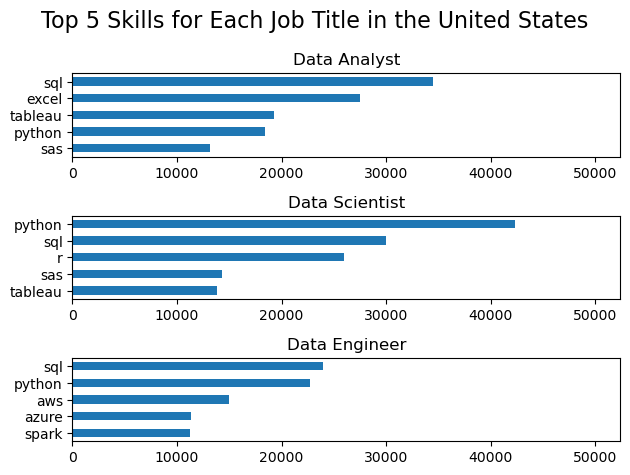

In [2]:
df_USA= df[df['job_country'] == 'United States'].copy()

df_skills = df_USA.copy()

df_skills = df_skills.explode('job_skills')

skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

last= df_skills_count['skill_count'].max()

fa, ax = plt.subplots(3,1)

for i, jobs in enumerate(job_titles):
    df_job = df_skills_count[df_skills_count['job_title_short'] == jobs].head(5)
    df_job.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], legend=False)
    ax[i].set_title(jobs)
    ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    ax[i].set_xlim(0, last + 10000)

plt.suptitle("Top 5 Skills for Each Job Title in the United States", fontsize=16)
plt.tight_layout()

In [3]:
df_job_title_counts = df_USA['job_title_short'].value_counts().reset_index(name='Job Total')

df_job_title_counts

,job_title_short,Job Total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


In [4]:
df_skills_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


In [5]:
df_skills_percent= pd.merge(df_skills_count, df_job_title_counts, how='left', on='job_title_short')
df_skills_percent['skill_percent'] = (df_skills_percent['skill_count'] / df_skills_percent['Job Total']) * 100
df_skills_percent

,job_skills,job_title_short,skill_count,Job Total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


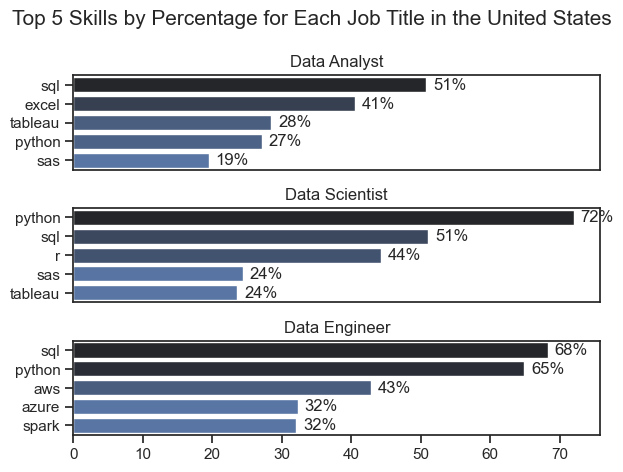

In [39]:
last = df_skills_percent['skill_percent'].max()
sns.set_theme(style='ticks')

fa, ax = plt.subplots(3,1)

for i, jobs in enumerate(job_titles):
    df_job = df_skills_percent[df_skills_percent['job_title_short'] == jobs].head(5)
    #df_job.plot(kind='barh', x='job_skills', y='skill_percent', ax=ax[i], legend=False)
    sns.barplot(data=df_job, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(jobs)
    ax[i].get_legend().remove()
    #ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    ax[i].set_xlabel("")
    ax[i].set_xlim(0, last)

    for n, v in enumerate(df_job['skill_percent']):
        ax[i].text(v+1,n,f'{v:.0f}%', va='center')

    if i != (len(job_titles)-1):
        ax[i].set_xticks([])

plt.suptitle("Top 5 Skills by Percentage for Each Job Title in the United States", fontsize=15)
fa.tight_layout(h_pad=0.5)
plt.tight_layout()

In [36]:
df_job

,job_skills,job_title_short,skill_count,Job Total,skill_percent
5,sql,Data Engineer,23958,35080,68.295325
6,python,Data Engineer,22762,35080,64.885975
9,aws,Data Engineer,15018,35080,42.810718
15,azure,Data Engineer,11321,35080,32.271950
16,spark,Data Engineer,11242,35080,32.046750


In [31]:
df_skills_percent.loc[1,'skill_percent']

np.float64(50.80217057921435)